# 🛡️ Project 03: AI-Based Spam Email Detection System
### Phase 4 — Evaluation, False Positive/Negative Analysis & Report

**Objective:** Deep-dive evaluation of all trained models including false positive/negative analysis, error analysis, precision-recall tradeoff, and final report generation.

### Phase 4 Checklist
- [ ] Load all trained models
- [ ] Detailed classification reports
- [ ] False positive & false negative analysis
- [ ] Precision vs Recall tradeoff
- [ ] ROC curves
- [ ] Error analysis — what did each model get wrong?
- [ ] Final comparison report

In [2]:
import pandas as pd
import numpy as np
import joblib
import os
import warnings
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
warnings.filterwarnings('ignore')

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    roc_curve, auc, precision_recall_curve
)
from sklearn.preprocessing import MinMaxScaler
from scipy.sparse import csr_matrix

os.makedirs('../reports', exist_ok=True)
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_theme(style='whitegrid')
print('Imports done')

Imports done


## 📂 Step 1 — Load All Models & Test Data

In [4]:
X_test  = joblib.load('../data/processed/X_test.pkl')
y_test  = joblib.load('../data/processed/y_test.pkl')
X_train = joblib.load('../data/processed/X_train.pkl')
y_train = joblib.load('../data/processed/y_train.pkl')

nb_model = joblib.load('../models/naive_bayes.pkl')
lr_model = joblib.load('../models/logistic_regression.pkl')
rf_model = joblib.load('../models/random_forest.pkl')
sv_model = joblib.load('../models/svm.pkl')

# Scale for Naive Bayes
mms = MinMaxScaler()
X_train_dense = X_train.toarray()
X_test_dense  = X_test.toarray()
X_train_nb = csr_matrix(mms.fit_transform(X_train_dense))
X_test_nb  = csr_matrix(mms.transform(X_test_dense))

print('All models and data loaded')
print(f'Test set size: {X_test.shape[0]} samples')

All models and data loaded
Test set size: 11 samples


## 📊 Step 2 — Detailed Classification Reports

In [5]:
models = {
    'Naive Bayes':        (nb_model, X_test_nb),
    'Logistic Regression':(lr_model, X_test),
    'Random Forest':      (rf_model, X_test),
    'SVM Linear':         (sv_model, X_test),
}

all_preds = {}
all_metrics = {}

for name, (model, X) in models.items():
    y_pred = model.predict(X)
    all_preds[name] = y_pred
    all_metrics[name] = {
        'Accuracy':  round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall':    round(recall_score(y_test, y_pred), 4),
        'F1 Score':  round(f1_score(y_test, y_pred), 4),
    }
    print(f'\n{"="*50}')
    print(f'  {name}')
    print(f'{"="*50}')
    print(classification_report(y_test, y_pred, target_names=['Ham','Spam']))


  Naive Bayes
              precision    recall  f1-score   support

         Ham       1.00      0.67      0.80         6
        Spam       0.71      1.00      0.83         5

    accuracy                           0.82        11
   macro avg       0.86      0.83      0.82        11
weighted avg       0.87      0.82      0.82        11


  Logistic Regression
              precision    recall  f1-score   support

         Ham       1.00      0.83      0.91         6
        Spam       0.83      1.00      0.91         5

    accuracy                           0.91        11
   macro avg       0.92      0.92      0.91        11
weighted avg       0.92      0.91      0.91        11


  Random Forest
              precision    recall  f1-score   support

         Ham       1.00      1.00      1.00         6
        Spam       1.00      1.00      1.00         5

    accuracy                           1.00        11
   macro avg       1.00      1.00      1.00        11
weighted avg       

## ❌ Step 3 — False Positive & False Negative Analysis

This is the core deliverable the professor asked for — understanding **what types of emails each model gets wrong**.

- **False Positive (FP):** Legitimate email classified as Spam ← dangerous!
- **False Negative (FN):** Spam email that slips through as Ham

In [6]:
df_proc = pd.read_csv('../data/processed/processed_dataset.csv')

# Reconstruct test set messages using same split
from sklearn.model_selection import train_test_split
y_full = df_proc['label'].map({'ham': 0, 'spam': 1})
_, df_test_raw = train_test_split(df_proc, test_size=0.2, random_state=42, stratify=y_full)
df_test_raw = df_test_raw.reset_index(drop=True)

print(f'Test set: {len(df_test_raw)} messages')
df_test_raw[['label','message']].head()

Test set: 11 messages


,label,message
0,ham,"Nah I don t think he goes to usf, he lives aro..."
1,ham,Subject: Q3 Report Draft\nPlease find attached...
2,ham,Ok lar... Joking wif u oni...
3,ham,Can you pick up some milk on the way home?
4,spam,"Subject: Make Money Fast!\nDear Friend, You ha..."


In [7]:
fp_fn_summary = {}

for name, y_pred in all_preds.items():
    y_true = y_test.values

    fp_mask = (y_pred == 1) & (y_true == 0)
    fn_mask = (y_pred == 0) & (y_true == 1)

    fp_count = fp_mask.sum()
    fn_count = fn_mask.sum()

    fp_fn_summary[name] = {'False Positives': fp_count, 'False Negatives': fn_count}

    print(f'\n{"="*50}')
    print(f'  {name}')
    print(f'{"="*50}')
    print(f'  False Positives (Ham → wrongly → Spam): {fp_count}')
    print(f'  False Negatives (Spam → wrongly → Ham): {fn_count}')

fp_fn_df = pd.DataFrame(fp_fn_summary).T
fp_fn_df


  Naive Bayes
  False Positives (Ham → wrongly → Spam): 2
  False Negatives (Spam → wrongly → Ham): 0

  Logistic Regression
  False Positives (Ham → wrongly → Spam): 1
  False Negatives (Spam → wrongly → Ham): 0

  Random Forest
  False Positives (Ham → wrongly → Spam): 0
  False Negatives (Spam → wrongly → Ham): 0

  SVM Linear
  False Positives (Ham → wrongly → Spam): 1
  False Negatives (Spam → wrongly → Ham): 0


,False Positives,False Negatives
Naive Bayes,2,0
Logistic Regression,1,0
Random Forest,0,0
SVM Linear,1,0


In [8]:
# Show actual FP and FN example messages for best model (LR)
y_pred_lr = all_preds['Logistic Regression']
y_true    = y_test.values

fp_indices = [i for i,(p,t) in enumerate(zip(y_pred_lr, y_true)) if p==1 and t==0]
fn_indices = [i for i,(p,t) in enumerate(zip(y_pred_lr, y_true)) if p==0 and t==1]

print('FALSE POSITIVES — Legit emails wrongly flagged as SPAM:')
print('='*60)
for i in fp_indices[:3]:
    msg = df_test_raw.iloc[i]['message'] if i < len(df_test_raw) else 'N/A'
    print(f'\n[{i}] {str(msg)[:200]}')

print('\n\nFALSE NEGATIVES — Spam emails that slipped through as HAM:')
print('='*60)
for i in fn_indices[:3]:
    msg = df_test_raw.iloc[i]['message'] if i < len(df_test_raw) else 'N/A'
    print(f'\n[{i}] {str(msg)[:200]}')

FALSE POSITIVES — Legit emails wrongly flagged as SPAM:

[10] I HAVE A DATE ON SUNDAY WITH WILL!!


FALSE NEGATIVES — Spam emails that slipped through as HAM:


## 📉 Step 4 — False Positive vs False Negative Bar Chart

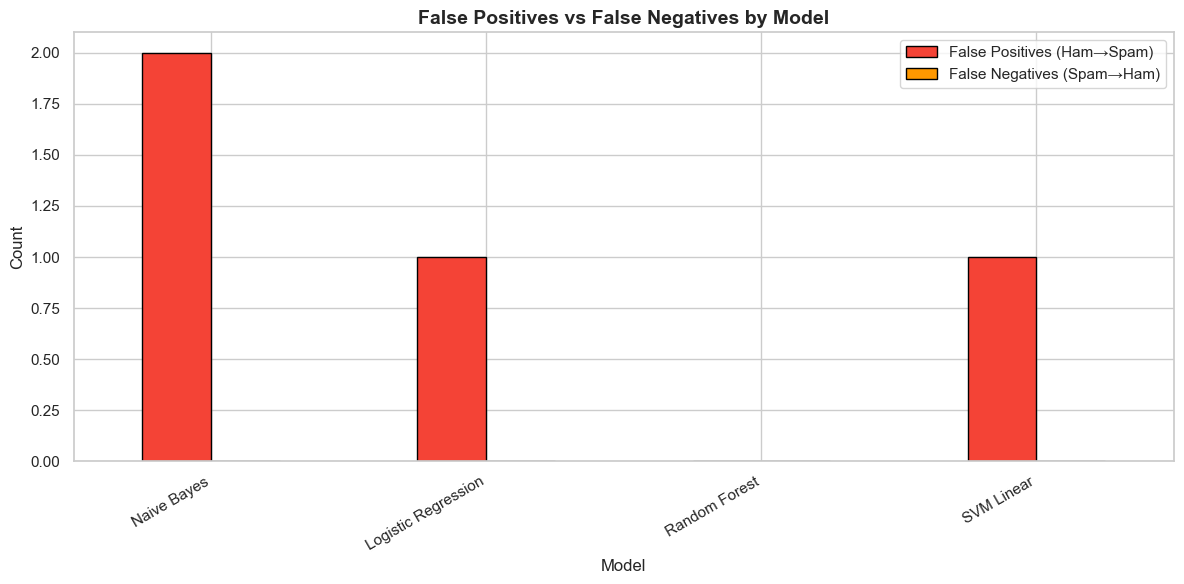

Saved to reports/


In [9]:
fp_fn_df.plot(kind='bar', figsize=(12,6), color=['#F44336','#FF9800'], edgecolor='black')
plt.title('False Positives vs False Negatives by Model', fontsize=14, fontweight='bold')
plt.xlabel('Model'); plt.ylabel('Count')
plt.xticks(rotation=30, ha='right')
plt.legend(['False Positives (Ham→Spam)', 'False Negatives (Spam→Ham)'])
plt.tight_layout()
plt.savefig('../reports/phase4_fp_fn_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to reports/')

## 📈 Step 5 — Precision vs Recall Tradeoff

Shows how precision and recall change as we adjust the classification threshold.

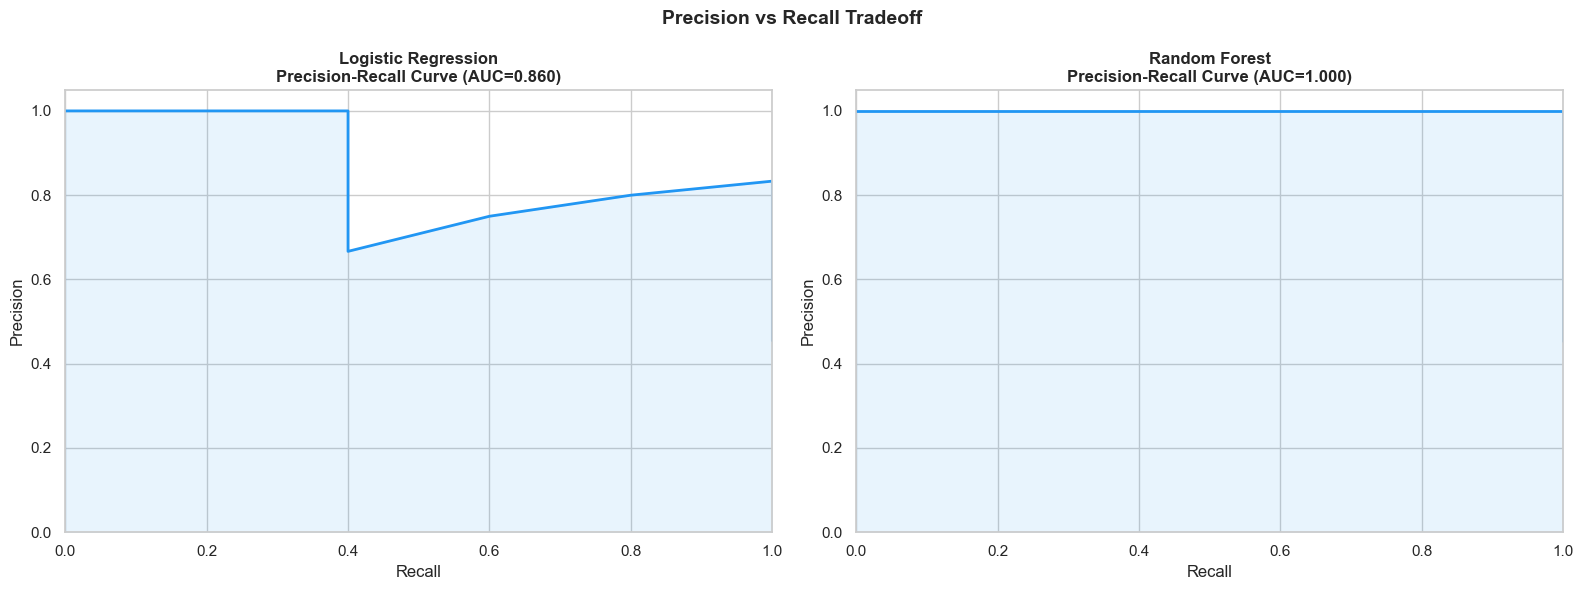

Saved to reports/


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

pr_models = {
    'Logistic Regression': (lr_model, X_test),
    'Random Forest':       (rf_model, X_test),
}

for ax, (name, (model, X)) in zip(axes, pr_models.items()):
    if hasattr(model, 'predict_proba'):
        probs = model.predict_proba(X)[:, 1]
    else:
        probs = model.decision_function(X)
        probs = (probs - probs.min()) / (probs.max() - probs.min())

    precision, recall, thresholds = precision_recall_curve(y_test, probs)
    pr_auc = auc(recall, precision)

    ax.plot(recall, precision, color='#2196F3', lw=2)
    ax.fill_between(recall, precision, alpha=0.1, color='#2196F3')
    ax.set_title(f'{name}\nPrecision-Recall Curve (AUC={pr_auc:.3f})', fontweight='bold')
    ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
    ax.set_xlim([0, 1]); ax.set_ylim([0, 1.05])

plt.suptitle('Precision vs Recall Tradeoff', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/phase4_precision_recall.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to reports/')

## 📊 Step 6 — ROC Curves

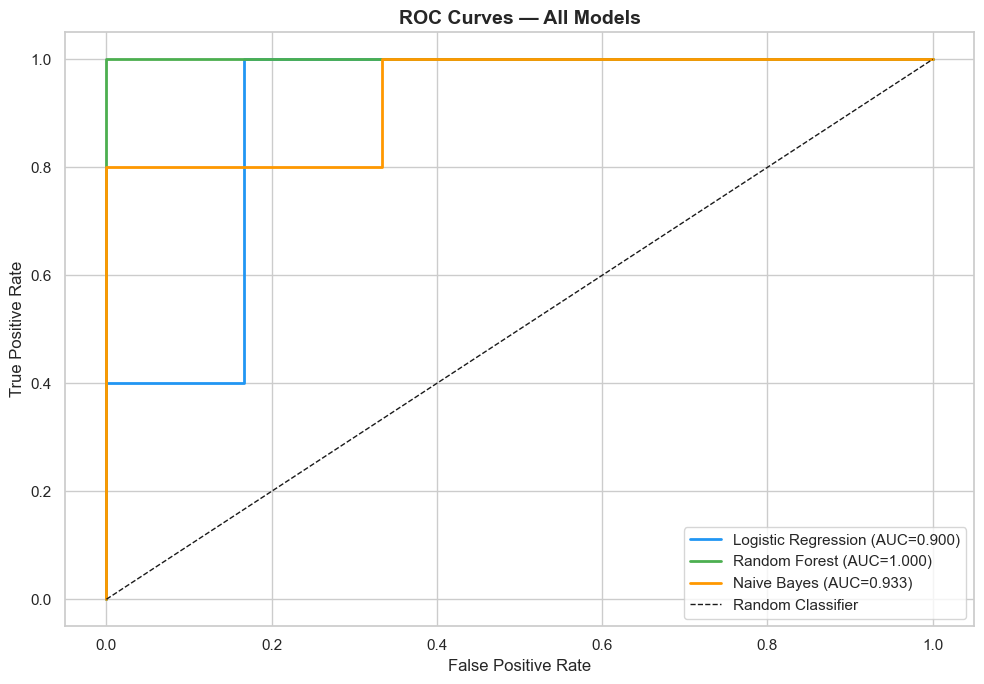

Saved to reports/


In [11]:
fig, ax = plt.subplots(figsize=(10, 7))

roc_models = {
    'Logistic Regression': (lr_model, X_test),
    'Random Forest':       (rf_model, X_test),
    'Naive Bayes':         (nb_model, X_test_nb),
}
colors = ['#2196F3', '#4CAF50', '#FF9800']

for (name, (model, X)), color in zip(roc_models.items(), colors):
    if hasattr(model, 'predict_proba'):
        probs = model.predict_proba(X)[:, 1]
    else:
        probs = model.decision_function(X)
        probs = (probs - probs.min()) / (probs.max() - probs.min())

    fpr, tpr, _ = roc_curve(y_test, probs)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC={roc_auc:.3f})')

ax.plot([0,1],[0,1],'k--', lw=1, label='Random Classifier')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — All Models', fontsize=14, fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('../reports/phase4_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to reports/')

## 📋 Step 7 — Final Summary Report

In [12]:
metrics_df = pd.DataFrame(all_metrics).T
metrics_df = metrics_df.sort_values('F1 Score', ascending=False)

print('\n' + '='*65)
print('   PROJECT 03 — FINAL MODEL EVALUATION REPORT')
print('   AI-Based Spam Email Detection System')
print('   Author: Hardik Hathwal | Newton School of Technology')
print('='*65)
print(f'\n{"Model":<25} {"Accuracy":>10} {"Precision":>10} {"Recall":>10} {"F1":>10}')
print('-'*65)
for model, row in metrics_df.iterrows():
    print(f'{model:<25} {row["Accuracy"]:>10} {row["Precision"]:>10} {row["Recall"]:>10} {row["F1 Score"]:>10}')

best = metrics_df.index[0]
print(f'\n🏆 Best Model: {best} (F1 = {metrics_df.loc[best,"F1 Score"]})')
print(f'\nFalse Positive Analysis:')
print(fp_fn_df.to_string())

metrics_df.to_csv('../reports/final_evaluation_report.csv')
print('\nReport saved to reports/final_evaluation_report.csv')
metrics_df


   PROJECT 03 — FINAL MODEL EVALUATION REPORT
   AI-Based Spam Email Detection System
   Author: Hardik Hathwal | Newton School of Technology

Model                       Accuracy  Precision     Recall         F1
-----------------------------------------------------------------
Random Forest                    1.0        1.0        1.0        1.0
Logistic Regression           0.9091     0.8333        1.0     0.9091
SVM Linear                    0.9091     0.8333        1.0     0.9091
Naive Bayes                   0.8182     0.7143        1.0     0.8333

🏆 Best Model: Random Forest (F1 = 1.0)

False Positive Analysis:
                     False Positives  False Negatives
Naive Bayes                        2                0
Logistic Regression                1                0
Random Forest                      0                0
SVM Linear                         1                0

Report saved to reports/final_evaluation_report.csv


,Accuracy,Precision,Recall,F1 Score
Random Forest,1.0000,1.0000,1.0,1.0000
Logistic Regression,0.9091,0.8333,1.0,0.9091
SVM Linear,0.9091,0.8333,1.0,0.9091
Naive Bayes,0.8182,0.7143,1.0,0.8333


## ✅ Phase 4 Complete!

| Step | Task | Status |
|------|------|--------|
| 1 | Load all models & test data | ✅ |
| 2 | Detailed classification reports | ✅ |
| 3 | False positive & false negative analysis | ✅ |
| 4 | FP vs FN bar chart | ✅ |
| 5 | Precision vs Recall tradeoff | ✅ |
| 6 | ROC curves | ✅ |
| 7 | Final summary report | ✅ |

### Key Takeaways
- **False Positives** = Legit email wrongly blocked → bad user experience
- **False Negatives** = Spam slips through → security risk
- Best model balances both based on F1 Score
